<a href="https://colab.research.google.com/github/marcos-mansur/load-forecast/blob/main/Notebook_8_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pendulum
from sklearn.base import BaseEstimator, TransformerMixin

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = False


# Load Files

In [2]:
def download_data(start, end):
    """load data from ONS"""

    first_year = f'https://ons-dl-prod-opendata.s3.amazonaws.com/dataset/carga_energia_di/CARGA_ENERGIA_{start}.csv'

    df_20XX = pd.read_csv(first_year, 
                        sep=';', 
                        parse_dates=['din_instante'])

    for x in range(start+1,end+1):
        df_20XX = pd.concat(objs = (df_20XX,pd.read_csv(os.path.join(f'https://ons-dl-prod-opendata.s3.amazonaws.com/',
                                                                    f'dataset/carga_energia_di/CARGA_ENERGIA_{x}.csv'), 
                            sep=';', 
                            parse_dates=['din_instante'])))
    return df_20XX

df_20XX = download_data(start=2009, end=2021)

load_col = 'val_cargaenergiamwmed'
time_col = 'din_instante'
regiao = 'SUDESTE'

# Treat data

In [3]:
class Preprocessor(BaseEstimator, TransformerMixin):

  def __init__(self, regiao):
    self.regiao = regiao
    self.missing_days = []
    pass


  def fit(self, df:pd.DataFrame):
    """ Learns the missing days """
    df = df.copy()
    # filter by subsystem
    df = self.filter_subsystem(df, regiao = self.regiao)
    # saves missing days in a variable called missing_days 
    self.missing_days = df[pd.isna(df.val_cargaenergiamwmed)].din_instante
    return self 


  def transform(self, df:pd.DataFrame):
    """ Applies transformations """
    df = df.copy()
    df = self.filter_subsystem(df, regiao = self.regiao)  # filter by subsystem
    df = self.impute_nan(df)                              # impute/drop NaN values
    df = self.go_to_friday(df)        # starts the dataset at a friday - the operative week 
    df = self.parse_dates(df)         # create columns parsing the data
    df = self.drop_incomplete_week(df)    # drop last rows so to have full weeks
    self.check_dq(df)                   # prints the NaN values for load and missing days
    return df


  def go_to_friday(self,df): 
    """ go next friday = begining of the operative week"""
    df = df.copy()
    # first day in dataset
    date_time = df['din_instante'].iloc[0]
    # check if the dataset starts on a friday 
    if date_time.day_name() != 'Friday':
      # today
      dt = pendulum.datetime(date_time.year,date_time.month, date_time.day)
      # next friday - begins the operative week
      next_friday = dt.next(pendulum.FRIDAY).strftime('%Y-%m-%d')
      # df starts with the begin of operative week
      df = df[df['din_instante'] >= next_friday].reset_index(drop=True).copy()
    
    return df


  def filter_subsystem(self, df:pd.DataFrame, regiao:str):
    """ filter data by subsystem and reset index """
    df = df.copy()
    # try and execept so it doesn't crash if it's applied to an already treated dataset
    try:
      df = df[df['nom_subsistema']==regiao].reset_index().drop('index',axis=1).copy()
    except:
      pass
    # dropa columns about subsystem
    df.drop(labels=['nom_subsistema','id_subsistema'], inplace=True, axis=1,errors='ignore')
    # reset index of concatenated datasets
    df.reset_index(inplace=True,drop=True)
    return df


  def parse_dates(self, df):
    """ parse date into year, month, month day and week day  """
    df = df.copy()
    
    df['semana'] = (df.index)//7
    df['dia semana'] = df['din_instante'].dt.day_name()
    df['dia mes'] = df['din_instante'].dt.day
    df['Mes'] = df['din_instante'].dt.month
    df['ano'] = df['din_instante'].dt.year
    return df

  def drop_incomplete_week(self,df):
    """ drop incomplete week at the bottom of the dataset """
    for i in range(6):
      if df['dia semana'].tail(1).item() == 'Thursday':
        break
      else:
        df.drop(labels=df.tail(1).index, axis=0, inplace=True)

    return df
  

  def impute_nan(self, df):
    """ impute the 12 NaN values """
    df = df.copy()
    time_col = 'din_instante'
    load_col = 'val_cargaenergiamwmed'
    if len(self.missing_days) != 0:
      # If the NaN weren't already dealt with:
      if df[df[time_col] == self.missing_days.iloc[0]].val_cargaenergiamwmed.isna().item():
        # impute missing day '2013-12-01' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[0]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[0] - 1]
        # impute missing day '2014-02-01' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[1]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[1] - 1]
        # impute missing day '2015-04-09' with the load from the day before
        df.at[(df[df.din_instante == self.missing_days.iloc[2]].index.item()), 
              load_col] = df[load_col].iloc[self.missing_days.index[2] - 1]
        # drop days from incomplete week in 2016 - from '2016-04-01' to '2016-04-14'
        df[time_col] = pd.to_datetime(df[time_col])
        df = df.drop(axis=0, index = df[(df[time_col] >= '2016-04-01') & (df[time_col] <= '2016-04-14')].index)
    
    return df
  

  def check_dq(self,df):
    # check for NaN values
    nan_data = df[pd.isna(df.val_cargaenergiamwmed)].din_instante
    if len(nan_data) != 0:
        print("NaN values: \n")
        print(nan_data)
    else:
        print('No missing NaN.')
    
    # check for missing days in the series
    missing_days = pd.date_range(start = df.din_instante.iloc[0], 
                                 end= df.din_instante.iloc[-1],
                                 freq='D').difference(df.din_instante)
    if len(missing_days) != 0:
        print("\nMissing days in the series:")
        print(missing_days)
    else:
        print("\nNo missing days in the series")

In [4]:
pp = Preprocessor(regiao='SUDESTE')
df = pp.fit_transform(df_20XX)

No missing NaN.

Missing days in the series:
DatetimeIndex(['2016-04-01', '2016-04-02', '2016-04-03', '2016-04-04',
               '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08',
               '2016-04-09', '2016-04-10', '2016-04-11', '2016-04-12',
               '2016-04-13', '2016-04-14'],
              dtype='datetime64[ns]', freq=None)


In [5]:
pp.missing_days

1795   2013-12-01
1857   2014-02-01
2289   2015-04-09
2651   2016-04-05
2652   2016-04-06
2653   2016-04-07
2654   2016-04-08
2655   2016-04-09
2656   2016-04-10
2657   2016-04-11
2658   2016-04-12
2659   2016-04-13
Name: din_instante, dtype: datetime64[ns]

# Visualize raw data

In [6]:
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['axes.grid'] = False

<function matplotlib.pyplot.show(close=None, block=None)>

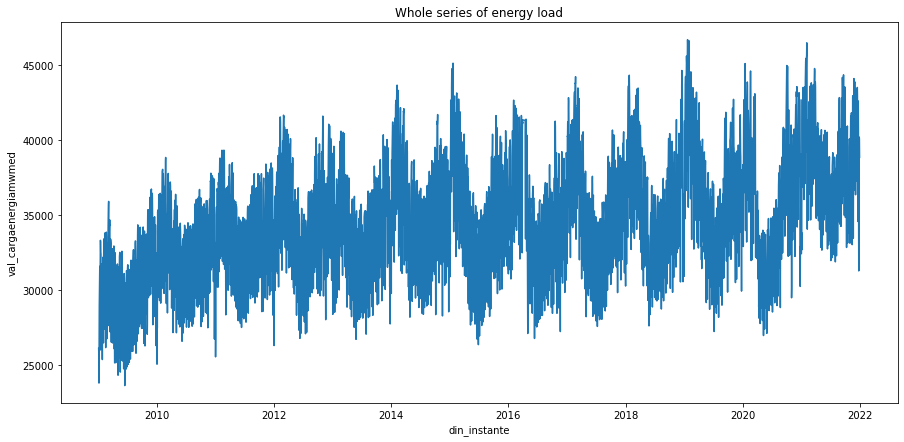

In [7]:
fig, ax = plt.subplots(figsize=(15,7))
sns.lineplot(x=pd.to_datetime(df[time_col]),y=df[load_col],ax=ax)
ax.set_title('Whole series of energy load')
plt.show

# Initialize constants

In [8]:
batch_size = 32
# target days to sum into weeks
target_period = 7 
# number of weeks in the window
n_weeks_ws = 20
# window size in days for each row
window_size = 7*n_weeks_ws
filepath = 'NB8.h5'
shuffle_buffer = 20
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# index of end of training dataset, start of validation dataset
split_val = int(len(df)*0.7)
# index of end of validation dataset, start of test dataset
split_test = int(len(df)*0.9)
# date when starts the validation and test sets 
date_val = df.iloc[split_val][time_col]
date_test = df.iloc[split_test][time_col]
# window_size date interval
delta_window = pd.to_timedelta(window_size,unit='d')
# split validation data date + window_size
d2 = date_val + delta_window
# split test data date + window_size
d3 = date_test + delta_window 


print('window_size = ',window_size)
print('validation set start date = ', date_val)
print('test set start date = ', date_test)

window_size =  140
validation set start date =  2018-02-10 00:00:00
test set start date =  2020-09-13 00:00:00


# Baseline

In [9]:
def create_target_df(df):
  """ returns a dataframe with target values and baseline"""
  # average daily load by operative week
  df_target = pd.DataFrame(data=df.groupby(by=['semana'])['val_cargaenergiamwmed'].mean())
  # start day of each operative week
  df_target['Data'] = df.groupby(by=['semana'])[time_col].min()
  df_target['dia semana'] = df.groupby(by=['semana'])['dia semana'].min()
  df_target['baseline'] = df_target['val_cargaenergiamwmed'].shift(1)
  return df_target

df_target = create_target_df(df)
df_target.tail()

,val_cargaenergiamwmed,Data,dia semana,baseline
semana,,,,
671,41951.631119,2021-11-26,Friday,40155.644786
672,40152.501982,2021-12-03,Friday,41951.631119
673,41609.216357,2021-12-10,Friday,40152.501982
674,39992.943000,2021-12-17,Friday,41609.216357
675,37119.563762,2021-12-24,Friday,39992.943000


In [10]:
# indexes for .loc for each set of data 
train_ix_base = ((df_target['Data'] < date_val) & (df_target['Data'] >= '2009-05-22'))
val_ix_base = ((df_target['Data'] > d2) & (df_target['Data']<date_test))
test_ix_base = df_target['Data']> d3


# metrics for baseline model
metrics_baseline = pd.DataFrame(index = ['train', 'val', 'test'], 
                       data = 

          {'MAE' : [tf.keras.metrics.mean_absolute_error(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],
           
          'MAPE' : [tf.keras.metrics.mape(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],
           
          'MSE' : [tf.keras.metrics.mse(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]],

          'MSLE' : [tf.keras.metrics.msle(
          df_target.loc[ix][load_col][1:],
          df_target.loc[ix]['baseline'][1:]).numpy() 
          for ix in [train_ix_base, val_ix_base, test_ix_base]]          
          })

metrics_baseline

,MAE,MAPE,MSE,MSLE
train,1070.513151,3.021482,2.067040e+06,0.001621
val,1280.296477,3.455976,3.044019e+06,0.002138
test,1004.067470,2.566258,1.735302e+06,0.001117


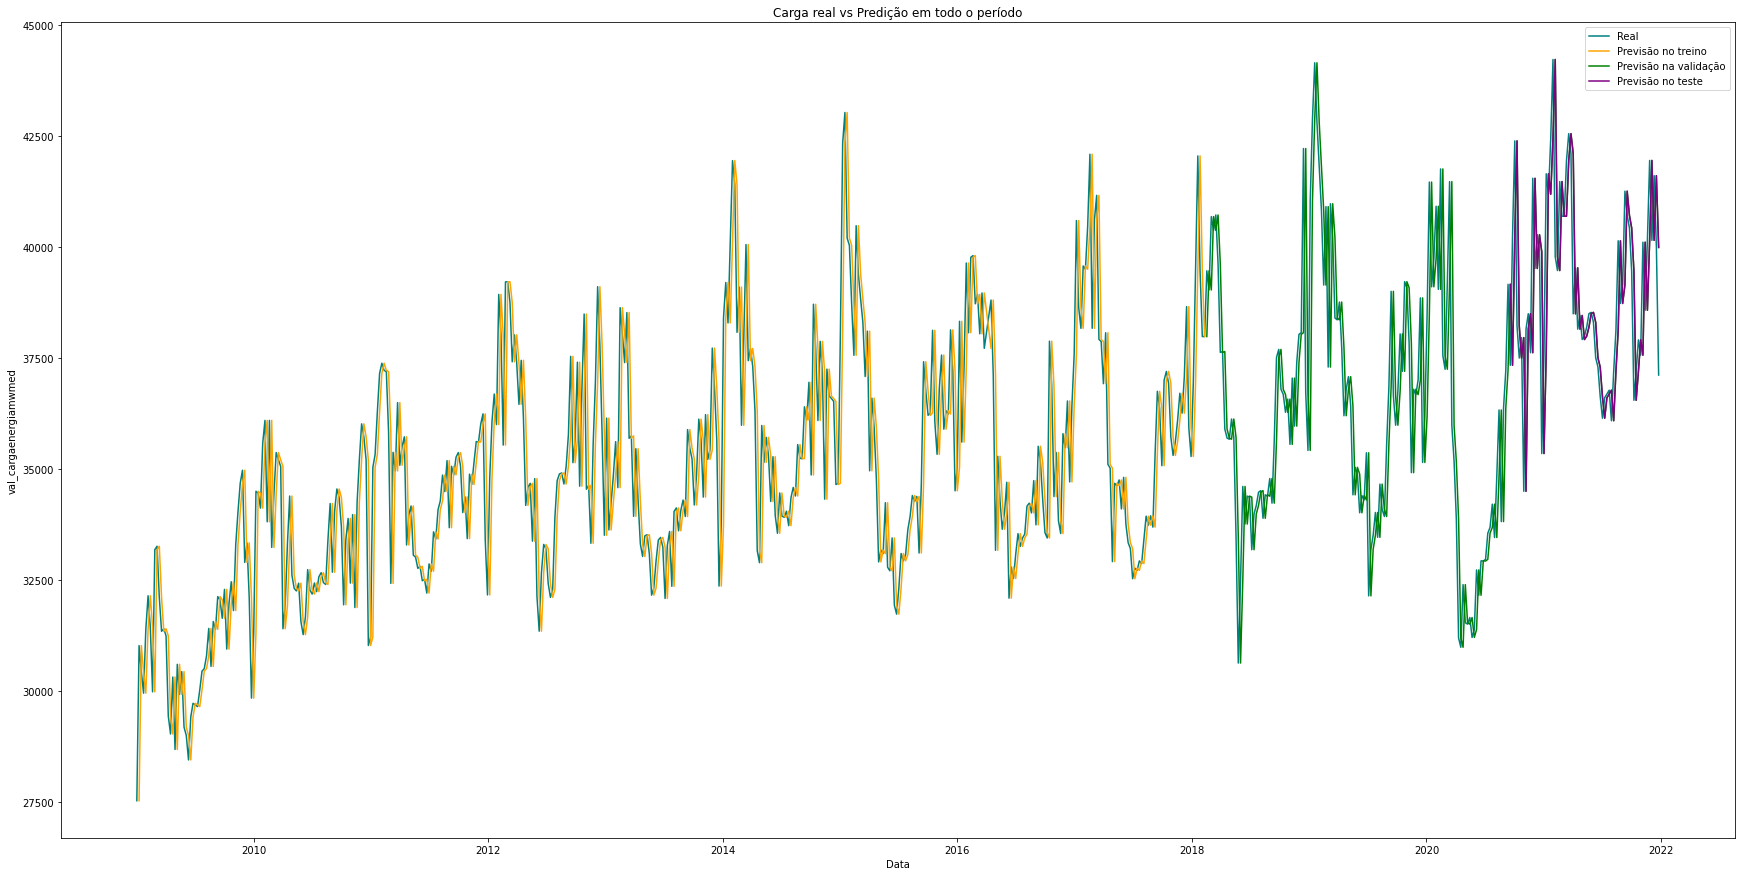

In [11]:
fix,ax=plt.subplots(figsize=(30, 15))

# plot measured data
sns.lineplot(x = df_target['Data'], 
             y = df_target[load_col], 
             ax=ax, color = 'teal')

# plot predicted training data
sns.lineplot(x = df_target.loc[df_target['Data']<date_val][1:].Data, 
             y = df_target.loc[df_target['Data']<date_val][1:].baseline,
             ax=ax, color='orange')

# plot predicted validation data
sns.lineplot(x = df_target[df_target['Data']>date_val].Data, 
             y = df_target[df_target['Data']>date_val].baseline,
             ax=ax, color='green')

# plot predicted test data
sns.lineplot(x = df_target[df_target['Data']>date_test].Data, 
             y = df_target[df_target['Data']>date_test].baseline,
             ax=ax, color='purple')

#plt.plot(df.din_instante[split_val:],np.array(forecast)[split_val-window_size:,0,0])
plt.title('Carga real vs Predição em todo o período')
plt.legend(['Real', 'Previsão no treino', 'Previsão na validação', 'Previsão no teste'])